# Exploratory Data Analysis (EDA)

## Bluestock Fintech – Mutual Fund Analytics Platform

### Objectives

- Analyze NAV trends (2022–2026)
- Study AUM growth
- Explore SIP inflows
- Understand investor demographics
- Analyze geographic distribution
- Evaluate fund correlations
- Study portfolio sector allocation
- Generate actionable business insights

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
fund = pd.read_csv(r"D:\Brainwave Bay\bluestock_mf_capstone\data\processed\clean_fund_master.csv")

nav = pd.read_csv(r"D:\Brainwave Bay\bluestock_mf_capstone\data\processed\clean_nav_history.csv")

aum = pd.read_csv(r"D:\Brainwave Bay\bluestock_mf_capstone\data\processed\clean_aum_by_fund_house.csv")

sip = pd.read_csv(r"D:\Brainwave Bay\bluestock_mf_capstone\data\processed\clean_monthly_sip_inflows.csv")

category = pd.read_csv(r"D:\Brainwave Bay\bluestock_mf_capstone\data\processed\clean_category_inflows.csv")

folio = pd.read_csv(r"D:\Brainwave Bay\bluestock_mf_capstone\data\processed\clean_industry_folio_count.csv")

performance = pd.read_csv(r"D:\Brainwave Bay\bluestock_mf_capstone\data\processed\clean_scheme_performance.csv")

transactions = pd.read_csv(r"D:\Brainwave Bay\bluestock_mf_capstone\data\processed\clean_investor_transactions.csv")

holdings = pd.read_csv(r"D:\Brainwave Bay\bluestock_mf_capstone\data\processed\clean_portfolio_holdings.csv")

benchmark = pd.read_csv(r"D:\Brainwave Bay\bluestock_mf_capstone\data\processed\clean_benchmark_indices.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

sip["month"] = pd.to_datetime(sip["month"])

folio["month"] = pd.to_datetime(folio["month"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [5]:
datasets = {
    "Fund Master": fund,
    "NAV History": nav,
    "AUM": aum,
    "Monthly SIP": sip,
    "Category Inflows": category,
    "Folio Count": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Fund Master,40,15
1,NAV History,46000,3
2,AUM,90,5
3,Monthly SIP,48,6
4,Category Inflows,144,3
5,Folio Count,21,6
6,Performance,40,21
7,Transactions,32778,13
8,Holdings,322,8
9,Benchmark,8050,3


In [6]:
missing = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Missing Values": [df.isnull().sum().sum() for df in datasets.values()]
})

missing

,Dataset,Missing Values
0,Fund Master,0
1,NAV History,0
2,AUM,0
3,Monthly SIP,12
4,Category Inflows,0
5,Folio Count,0
6,Performance,0
7,Transactions,0
8,Holdings,0
9,Benchmark,0


In [7]:
for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print(df.info())

Fund Master
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB
None

In [8]:
performance.describe()

,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000
std,14534.998667,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484
min,100016.000000,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000
25%,118632.750000,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000
50%,119551.500000,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000
75%,120842.250000,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000
max,149324.000000,24.930000,23.390000,23.800000,22.160000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,49046.00000,1.640000,5.000000


# 1. NAV Trend Analysis (2022–2026)

This section visualizes the daily NAV movement of all mutual fund schemes. It highlights the broad market bull run during 2023 and the market correction during early 2024.

In [9]:
nav_plot = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.10,
    annotation_text="2023 Bull Run",
    line_width=0
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.10,
    annotation_text="2024 Market Correction",
    line_width=0
)

fig.update_layout(
    height=700,
    template="plotly_white"
)

fig.show()

In [10]:
fig.write_image(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\nav_trend.png"
)

## Insight 1

The majority of mutual fund schemes exhibited an upward NAV trend from 2022 to 2026. A strong bull market is visible during 2023, while a temporary correction occurred during early 2024 before recovery.

# 2. AUM Growth Analysis (2022–2025)

This section compares the Assets Under Management (AUM) of all fund houses from 2022 to 2025. It highlights SBI Mutual Fund's market dominance.

In [11]:
# View the data first
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [12]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [13]:
# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Verify
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


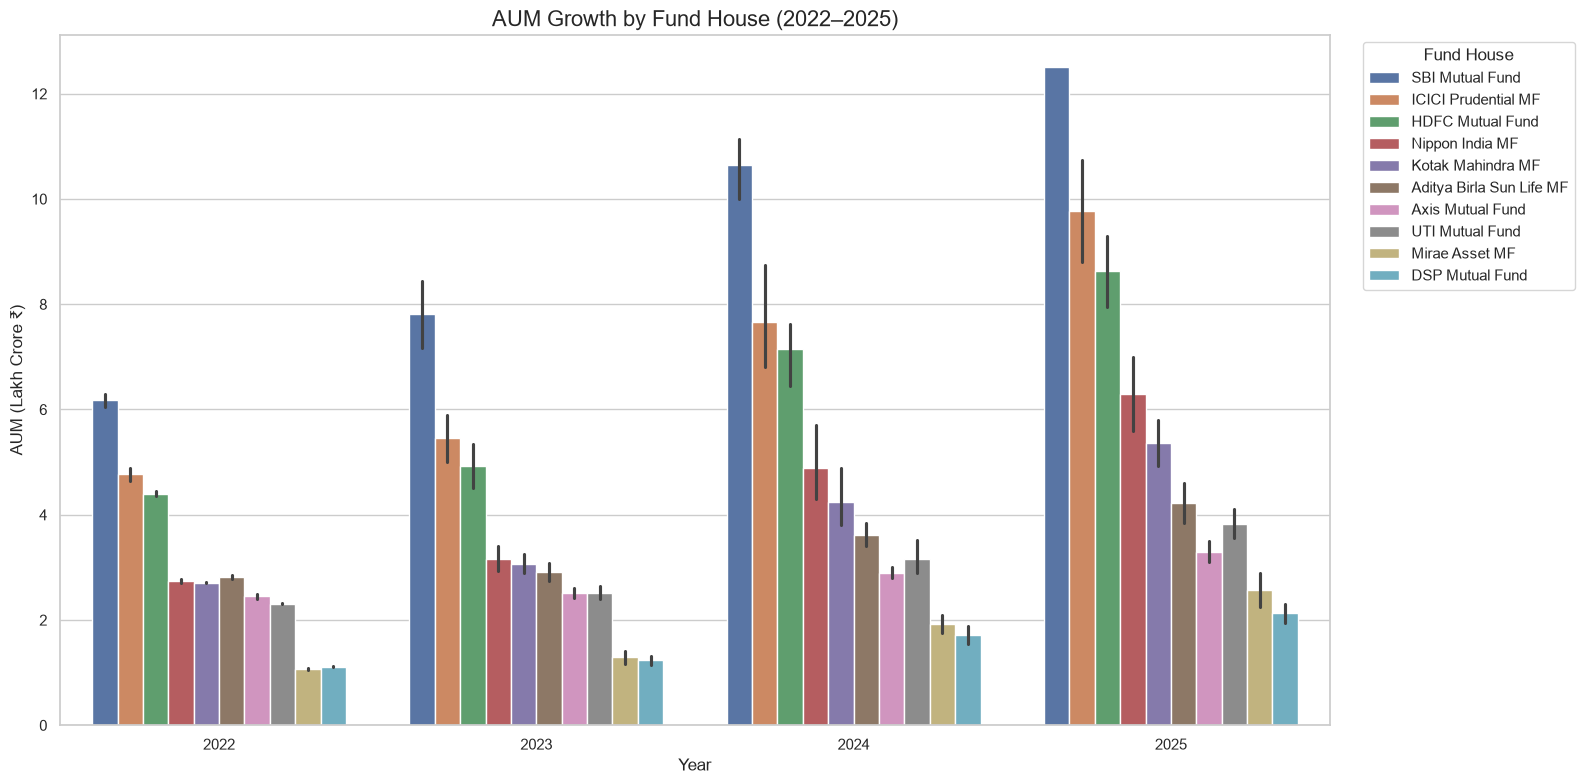

In [14]:
plt.figure(figsize=(16,8))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=0)
plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.show()

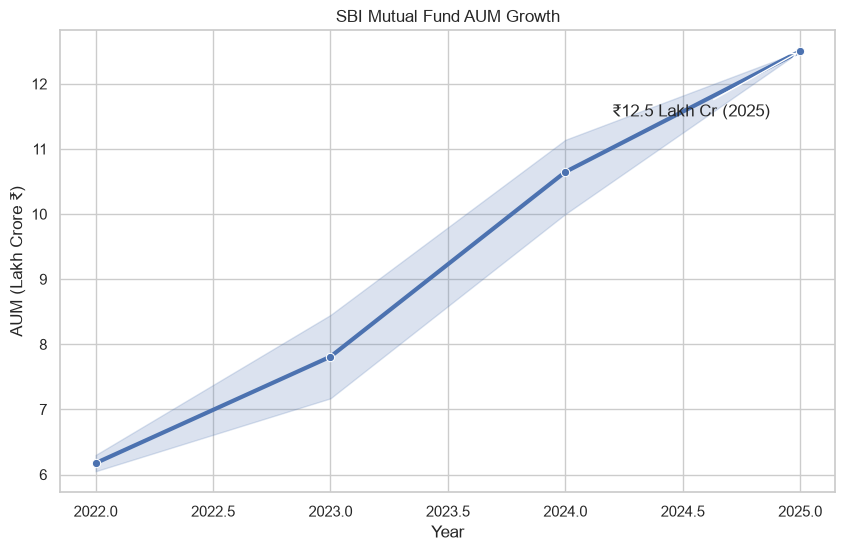

In [15]:
sbi = aum[aum["fund_house"]=="SBI Mutual Fund"]

plt.figure(figsize=(10,6))

sns.lineplot(
    data=sbi,
    x="year",
    y="aum_lakh_crore",
    marker="o",
    linewidth=3
)

plt.annotate(
    "₹12.5 Lakh Cr (2025)",
    xy=(2025,12.5),
    xytext=(2024.2,11.5),
    arrowprops=dict(arrowstyle="->")
)

plt.title("SBI Mutual Fund AUM Growth")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.show()

In [16]:
plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

### Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management among all fund houses. By 2025 it crossed ₹12.5 lakh crore, reflecting its dominant position in the Indian mutual fund industry.

# 3. Monthly SIP Inflow Trend (2022–2025)

This visualization tracks the monthly SIP inflows from January 2022 to December 2025 and highlights the record SIP inflow of ₹31,002 crore in December 2025.

In [17]:
sip.head()
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [18]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)"
)

fig.update_traces(
    line=dict(width=3)
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    height=600
)

fig.show()

In [25]:
# Find the highest SIP inflow row
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

# Convert Timestamp to string
max_date = max_row["month"].strftime("%Y-%m-%d")

# Add annotation
fig.add_annotation(
    x=max_date,
    y=float(max_row["sip_inflow_crore"]),
    text=f"₹{int(max_row['sip_inflow_crore']):,} Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    bgcolor="yellow",
    bordercolor="black"
)

fig.show()

In [26]:
fig.write_image(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\sip_trend.png"
)

# 4. Category Inflow Heatmap

This heatmap visualizes monthly net inflows across different mutual fund categories. Darker colors indicate higher inflows, helping identify category-wise investment trends over time.

In [27]:
category.head()
print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


In [28]:
category["month"] = pd.to_datetime(category["month"])

In [29]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


In [30]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


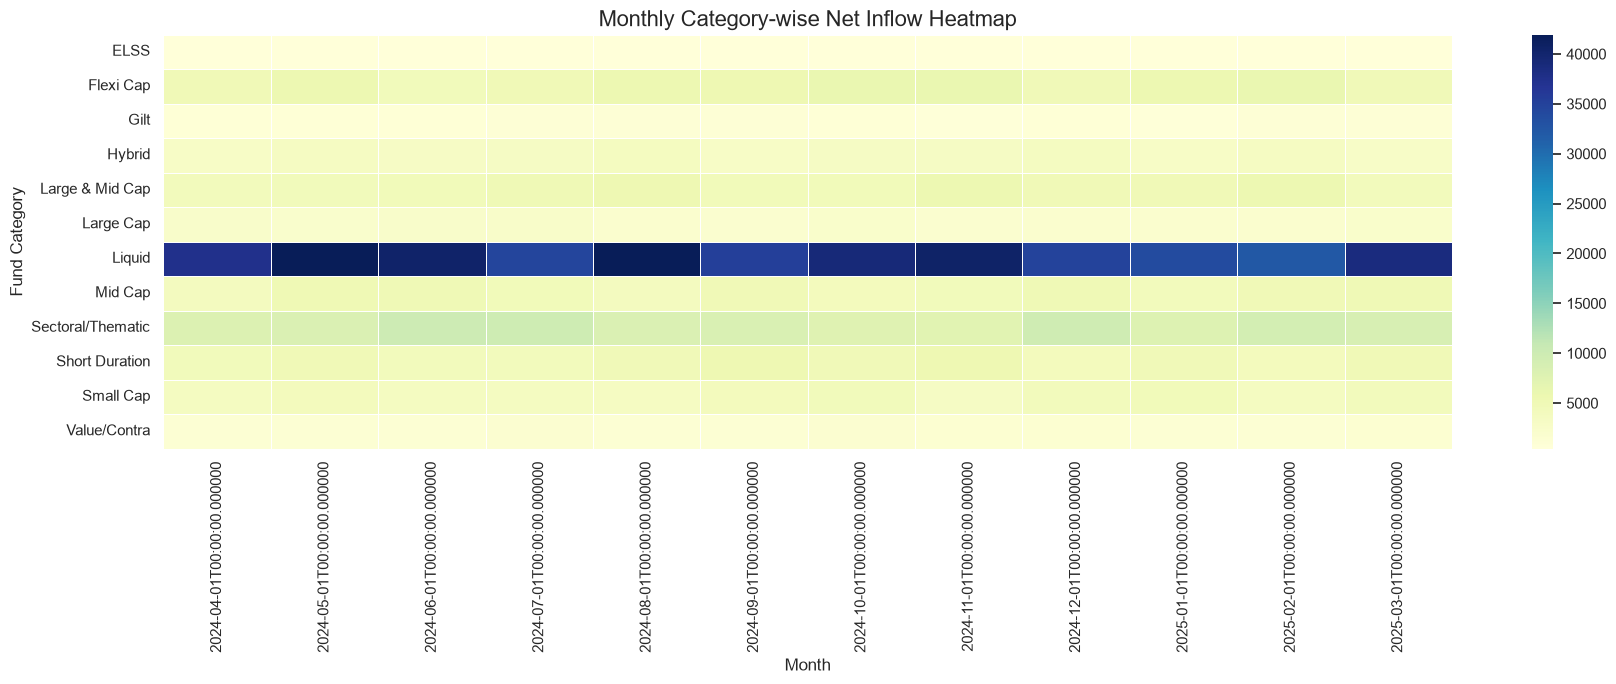

In [31]:
plt.figure(figsize=(18,7))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=False
)

plt.title(
    "Monthly Category-wise Net Inflow Heatmap",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

In [32]:
plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

### Insight 4

Equity-oriented mutual fund categories consistently recorded stronger monthly inflows than debt-oriented categories. Seasonal fluctuations are visible, while sustained inflows indicate continued investor confidence in equity markets.

In [33]:
transactions.head()
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


# 5. Investor Demographics

This section analyzes investor demographics including age group distribution, gender distribution, and SIP investment behaviour across different age groups.

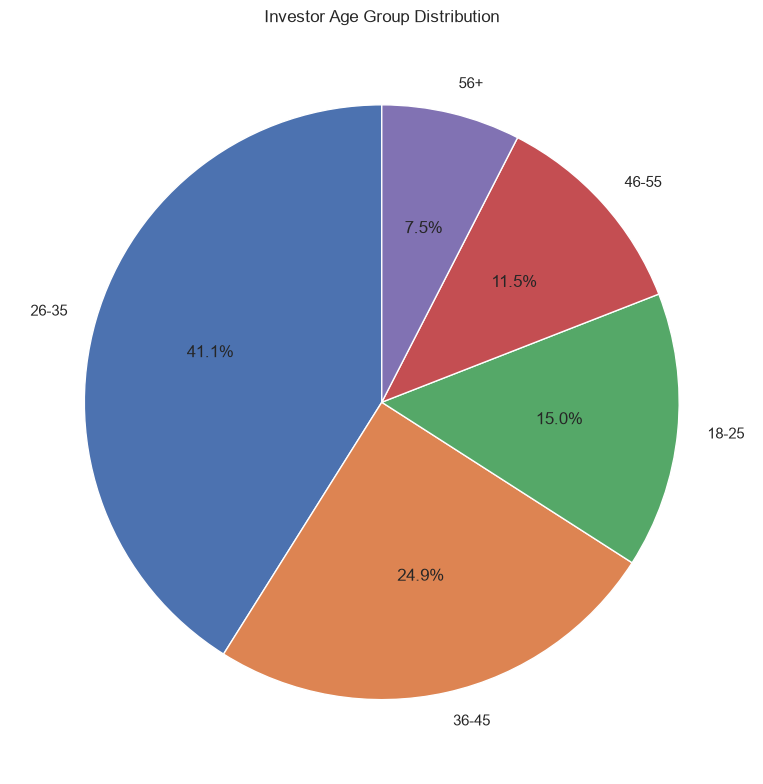

In [35]:
plt.figure(figsize=(8,8))

age_counts = transactions["age_group"].value_counts()

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\age_group_distribution.png",
    dpi=300
)

plt.show()

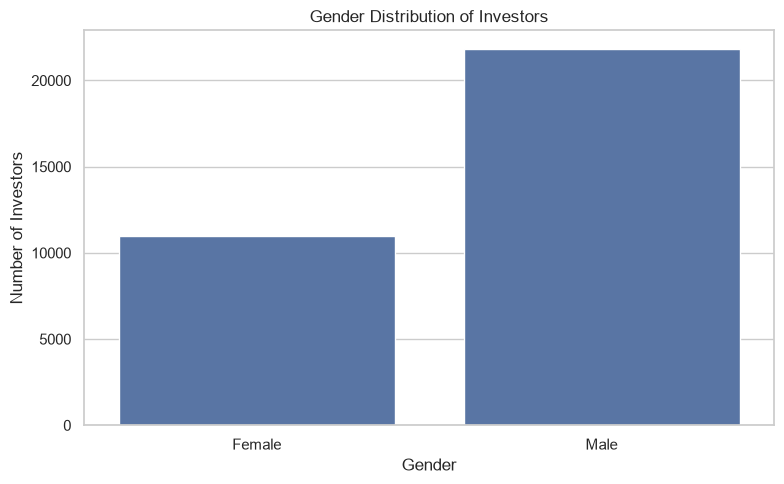

In [36]:
#Gender Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\gender_distribution.png",
    dpi=300
)

plt.show()

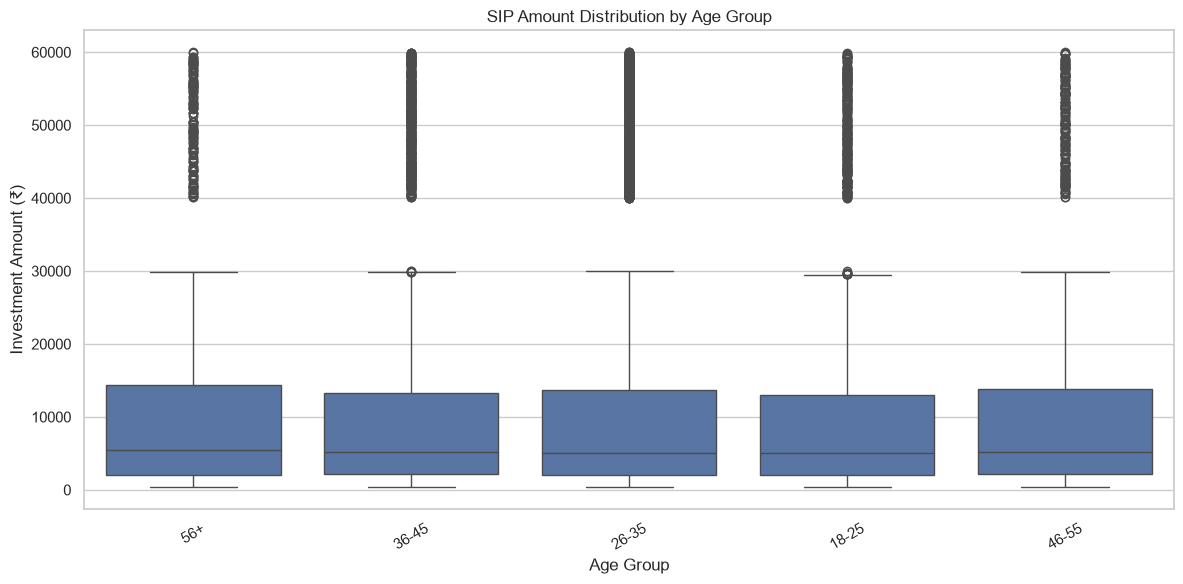

In [37]:
# SIP Amount by Age Group - Box Plot
sip_transactions = transactions[
    transactions["transaction_type"] == "Sip"
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\sip_boxplot_age.png",
    dpi=300
)

plt.show()

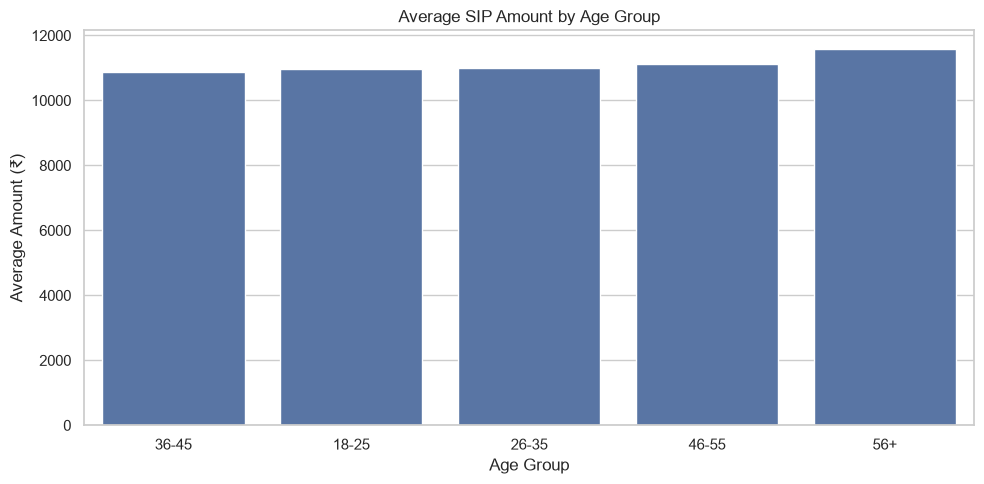

In [38]:
#Average SIP Amount by Age Group
plt.figure(figsize=(10,5))

avg_sip = (
    sip_transactions
    .groupby("age_group")["amount_inr"]
    .mean()
    .sort_values()
)

sns.barplot(
    x=avg_sip.index,
    y=avg_sip.values
)

plt.title("Average SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Amount (₹)")

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\avg_sip_age.png",
    dpi=300
)

plt.show()

### Insight 5

The majority of investors belong to the younger and middle-age groups, indicating strong retail participation. SIP investment amounts vary across age groups, with higher median investments generally observed among older investors.

# 6. Geographic Distribution

This section analyzes investor participation across different states and compares investments from T30 and B30 city tiers.

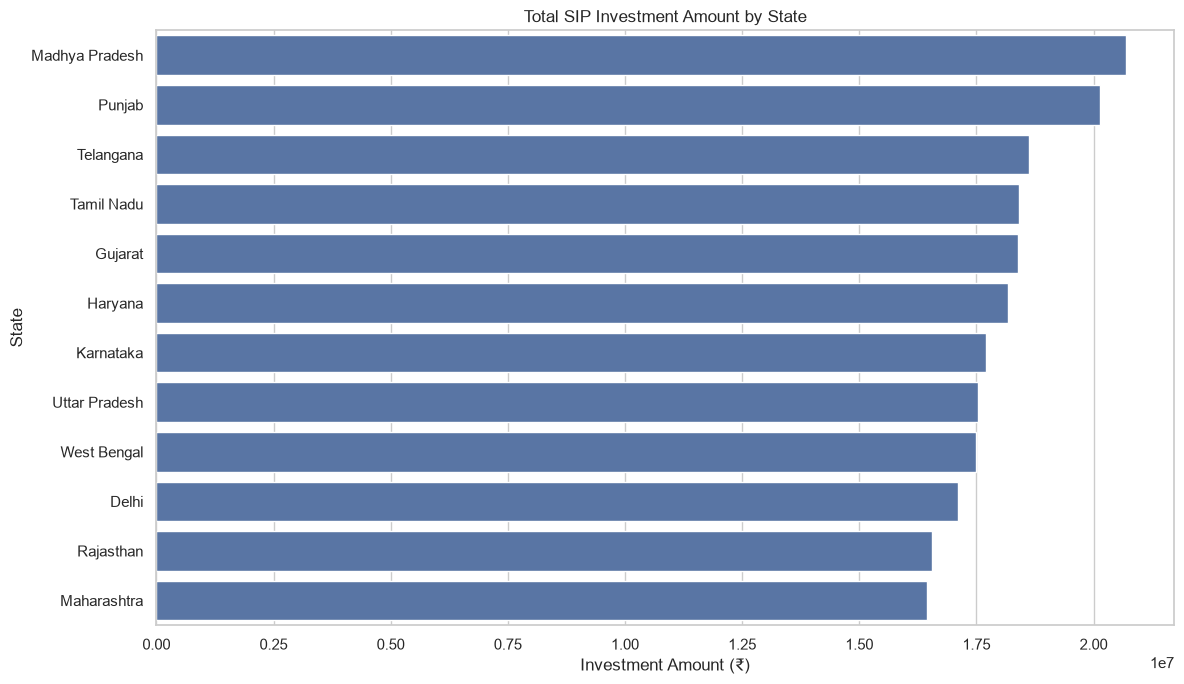

In [42]:
# State-wise SIP Amount
state_sip = (
    transactions[transactions["transaction_type"] == "Sip"]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\state_sip.png",
    dpi=300
)

plt.show()

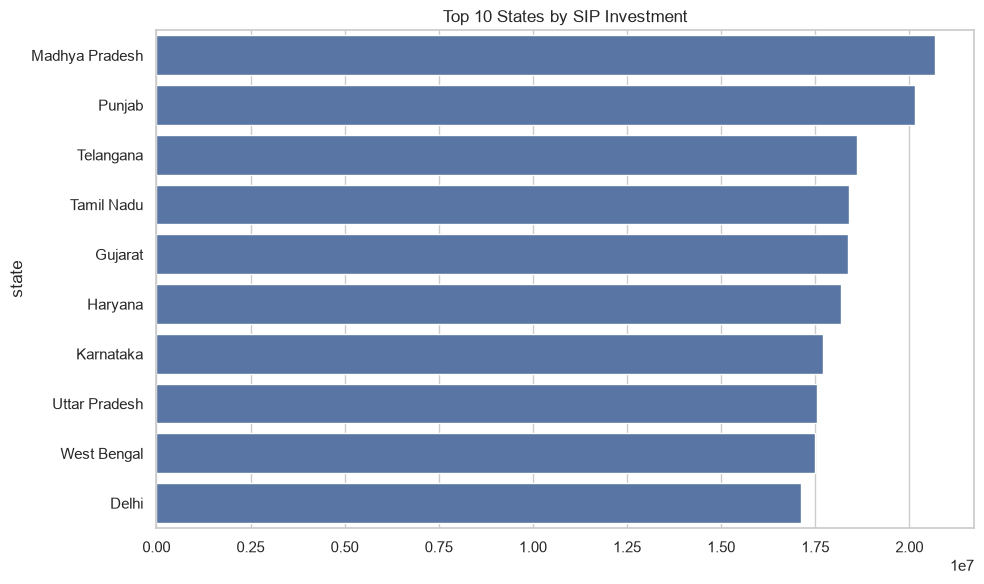

In [43]:
# Top 10 States by SIP Investment
top10 = state_sip.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States by SIP Investment")

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\top10_states.png",
    dpi=300
)

plt.show()

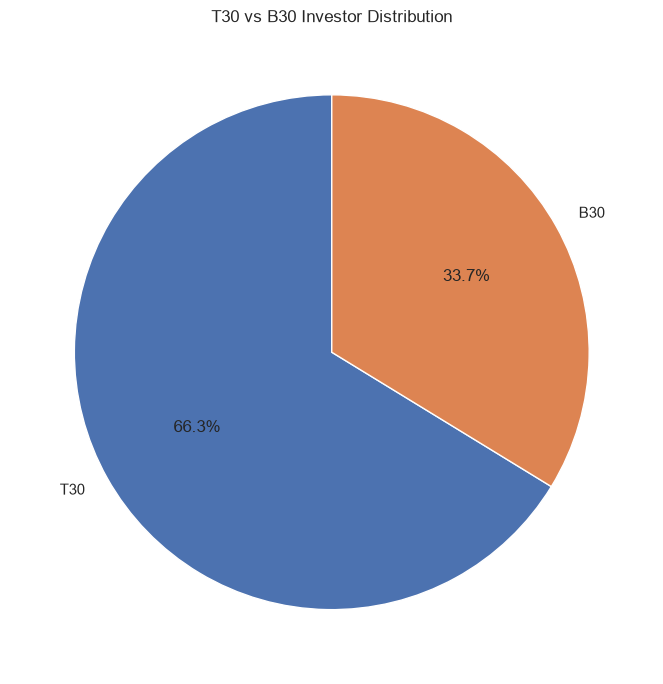

In [44]:
# T30 vs B30 Pie Chart
tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\t30_b30.png",
    dpi=300
)

plt.show()

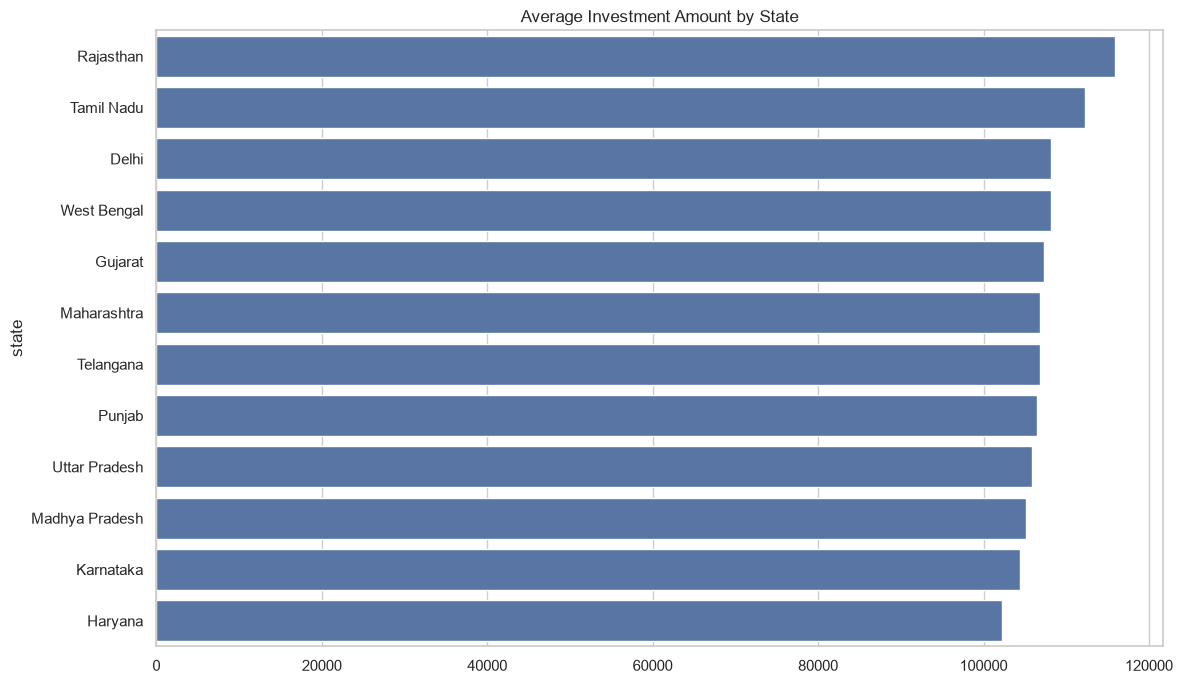

In [45]:
#State-wise Average Investment
avg_state = (
    transactions
    .groupby("state")["amount_inr"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=avg_state.values,
    y=avg_state.index
)

plt.title("Average Investment Amount by State")

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\avg_state_amount.png",
    dpi=300
)

plt.show()

### Insight 6

Metropolitan and financially active states contribute the highest SIP investment volumes. T30 cities account for a significant share of investments, while B30 cities continue to show healthy participation, indicating expanding mutual fund adoption beyond major urban centers.

# 7. Folio Count Growth

This section visualizes the growth in mutual fund folios between 2022 and 2025, highlighting the increasing participation of investors.

In [46]:
print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [47]:
folio["month"] = pd.to_datetime(folio["month"])

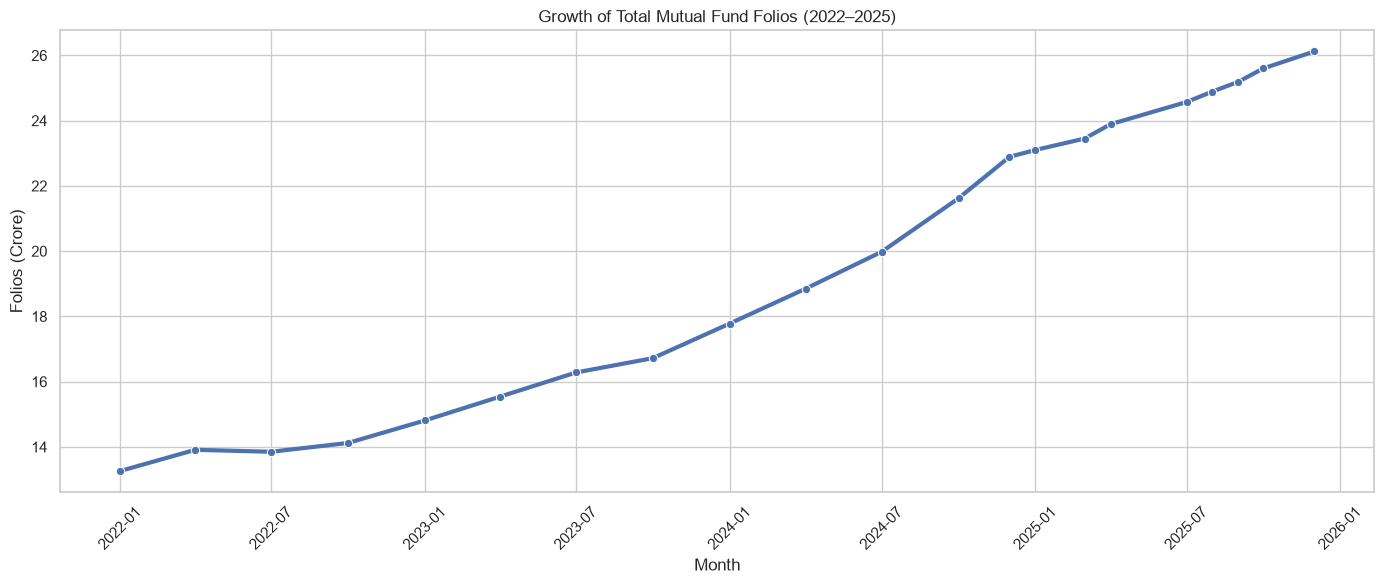

In [48]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore",
    marker="o",
    linewidth=3
)

plt.title("Growth of Total Mutual Fund Folios (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\folio_growth.png",
    dpi=300
)

plt.show()

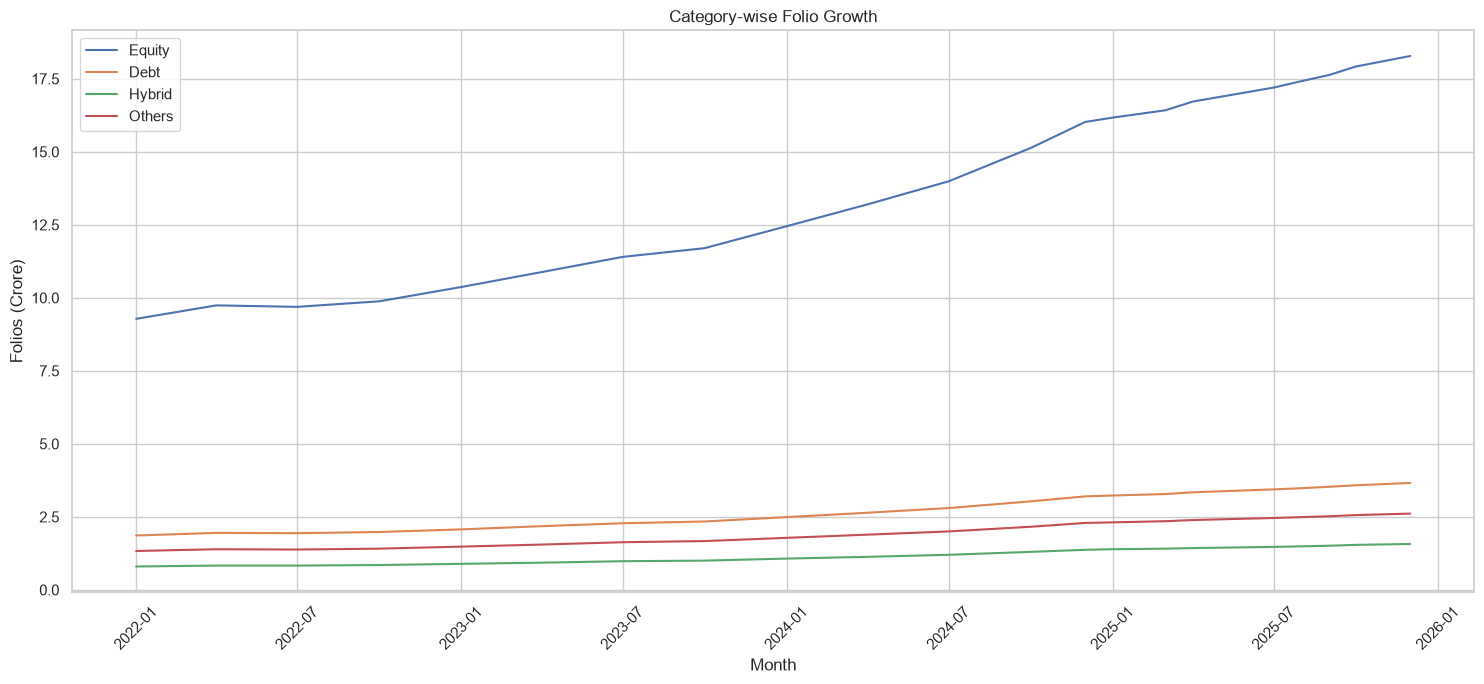

In [49]:
plt.figure(figsize=(15,7))

plt.plot(folio["month"], folio["equity_folios_crore"], label="Equity")
plt.plot(folio["month"], folio["debt_folios_crore"], label="Debt")
plt.plot(folio["month"], folio["hybrid_folios_crore"], label="Hybrid")
plt.plot(folio["month"], folio["others_folios_crore"], label="Others")

plt.title("Category-wise Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\folio_categories.png",
    dpi=300
)

plt.show()

### Insight 7

Total mutual fund folios increased steadily throughout the analysis period, with equity funds contributing the largest share of overall folio growth, reflecting sustained retail participation.

# 8. NAV Return Correlation Matrix

This analysis measures the relationship between daily NAV returns of selected mutual fund schemes.

In [51]:
selected = nav["amfi_code"].unique()[:10]

nav10 = nav[nav["amfi_code"].isin(selected)]

pivot = nav10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change().dropna()

corr = returns.corr()

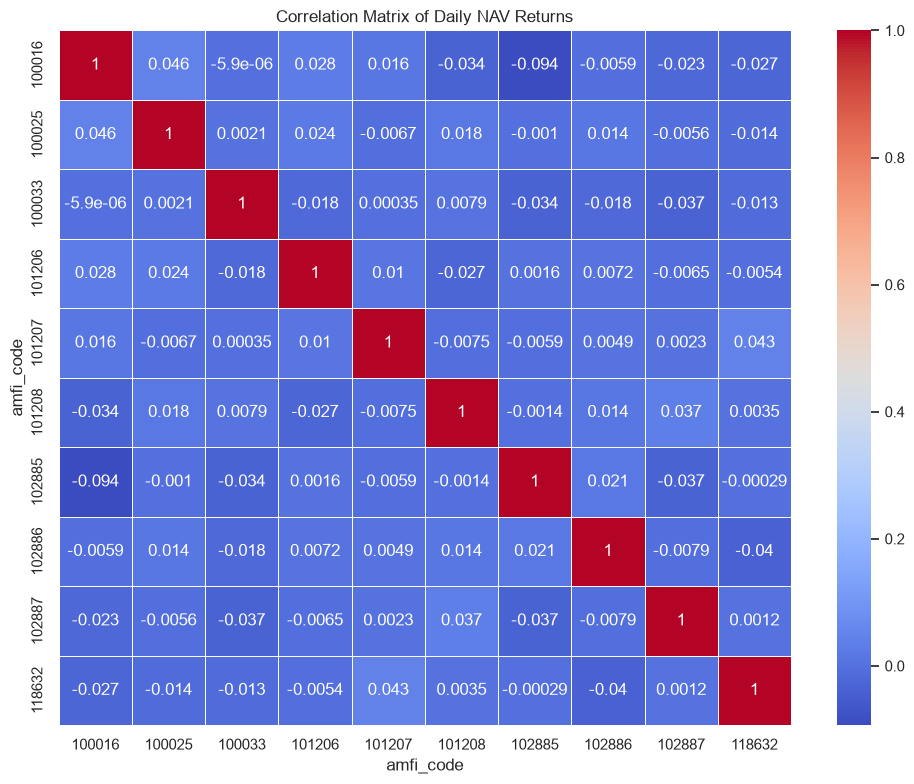

In [52]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\nav_correlation.png",
    dpi=300
)

plt.show()

### Insight 8

Most equity-oriented mutual funds exhibit positive correlations in daily NAV movements, indicating that broader market conditions influence multiple schemes simultaneously.

In [53]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


# 9. Sector Allocation Analysis

This section analyzes the portfolio allocation across different industry sectors using the portfolio holdings dataset. The donut chart highlights the relative sector weights across all equity mutual funds.

In [54]:
sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

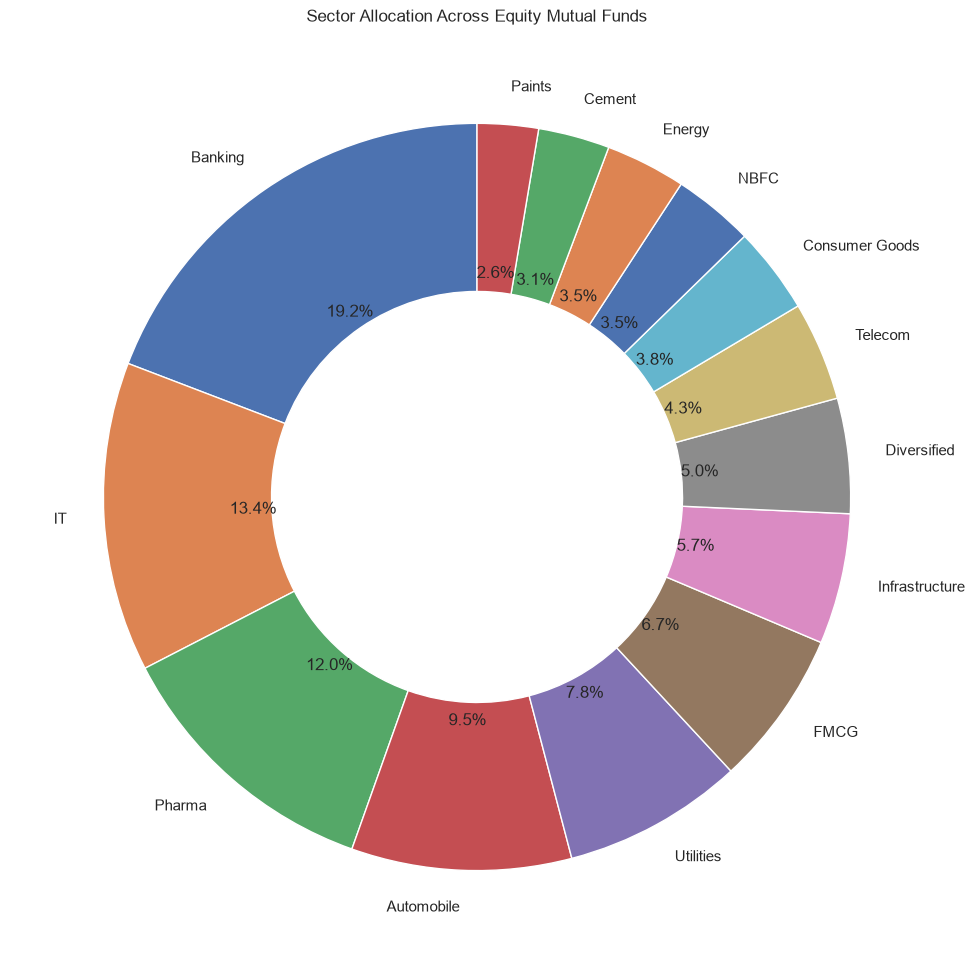

In [55]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Sector Allocation Across Equity Mutual Funds")

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\sector_allocation_donut.png",
    dpi=300
)

plt.show()

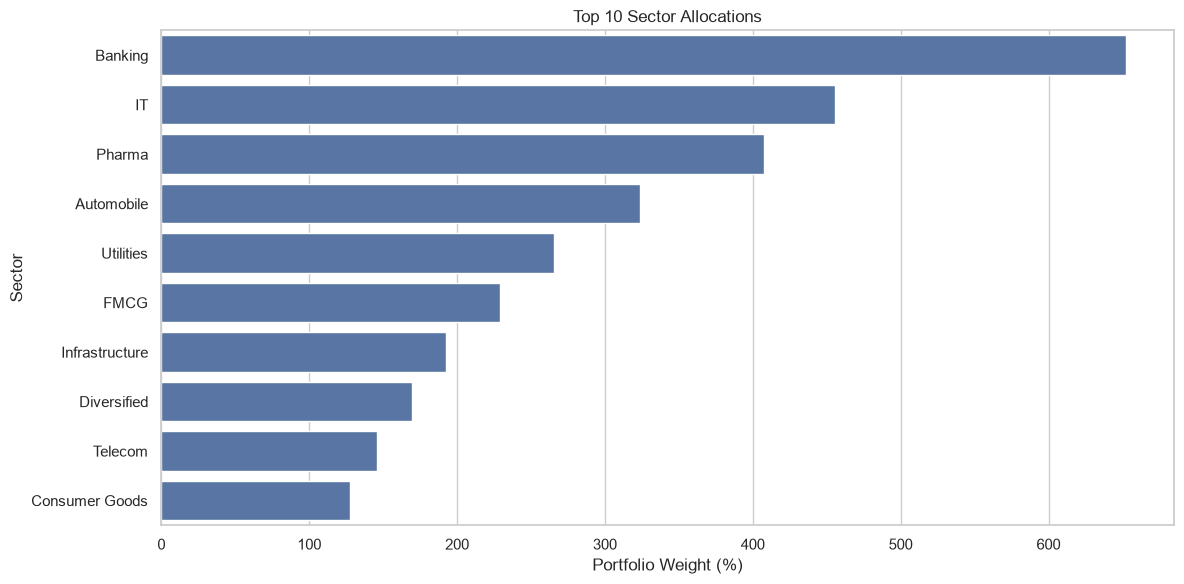

In [56]:
# Top 10 Sector Allocations
top_sector = sector_data.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_sector.values,
    y=top_sector.index
)

plt.title("Top 10 Sector Allocations")
plt.xlabel("Portfolio Weight (%)")
plt.ylabel("Sector")

plt.tight_layout()

plt.savefig(
    r"D:\Brainwave Bay\bluestock_mf_capstone\reports\charts\top10_sectors.png",
    dpi=300
)

plt.show()

### Insight 9

Financial Services, Information Technology, Healthcare and Banking contribute the largest share of portfolio allocation, indicating a strong preference for stable and high-growth sectors among equity mutual funds.

# 10. Key Business Insights

1. Mutual fund NAVs displayed an overall upward trend from 2022–2025 despite temporary market corrections.

2. SBI Mutual Fund maintained the highest Assets Under Management among all fund houses.

3. Monthly SIP inflows reached a record high of ₹31,002 crore in December 2025.

4. Equity-oriented categories consistently attracted higher inflows than debt-oriented categories.

5. Younger and middle-aged investors account for a significant proportion of mutual fund investments.

6. Metropolitan (T30) cities contribute the largest investment volumes, while B30 participation continues to grow.

7. Total folio counts increased steadily, indicating expanding retail participation.

8. Most mutual fund schemes exhibit positive return correlations due to common market movements.

9. Financial Services and Information Technology dominate portfolio sector allocation.

10. The Indian mutual fund industry demonstrated consistent long-term growth in AUM, SIP inflows, investor participation, and portfolio diversification.

In [57]:
print("="*60)
print("Exploratory Data Analysis Completed Successfully")
print("="*60)

print("\nCharts Generated:")
print("- NAV Trend")
print("- AUM Growth")
print("- SIP Trend")
print("- Category Heatmap")
print("- Age Distribution")
print("- Gender Distribution")
print("- SIP Box Plot")
print("- Average SIP by Age")
print("- State-wise SIP")
print("- Top 10 States")
print("- T30 vs B30")
print("- Average Investment by State")
print("- Folio Growth")
print("- Category-wise Folios")
print("- NAV Correlation Matrix")
print("- Sector Allocation Donut")
print("- Top 10 Sectors")

print("\nEDA Notebook Ready for Submission")

Exploratory Data Analysis Completed Successfully

Charts Generated:
- NAV Trend
- AUM Growth
- SIP Trend
- Category Heatmap
- Age Distribution
- Gender Distribution
- SIP Box Plot
- Average SIP by Age
- State-wise SIP
- Top 10 States
- T30 vs B30
- Average Investment by State
- Folio Growth
- Category-wise Folios
- NAV Correlation Matrix
- Sector Allocation Donut
- Top 10 Sectors

EDA Notebook Ready for Submission
